In [2]:
import pandas as pd
import matplotlib.pyplot as plt


df = pd.read_csv("../data/processed/model_ready_data.csv")

df.head()

,SeniorCitizen,tenure,MonthlyCharges,Churn,monthly_revenue,annual_revenue,lifetime_value,usage_trend_3m,support_ticket_count,inactivity_score,...,TotalCharges_995.35,TotalCharges_996.45,TotalCharges_996.85,TotalCharges_996.95,TotalCharges_997.65,TotalCharges_997.75,TotalCharges_998.1,TotalCharges_999.45,TotalCharges_999.8,TotalCharges_999.9
0,0,1,29.85,0,29.85,358.2,29.85,-1.538208,1,0.229976,...,False,False,False,False,False,False,False,False,False,False
1,0,34,56.95,0,56.95,683.4,1936.30,-0.601338,2,0.936928,...,False,False,False,False,False,False,False,False,False,False
2,0,2,53.85,1,53.85,646.2,107.70,-1.143142,2,0.454705,...,False,False,False,False,False,False,False,False,False,False
3,0,45,42.30,0,42.30,507.6,1903.50,1.753199,1,0.043289,...,False,False,False,False,False,False,False,False,False,False
4,0,2,70.70,1,70.70,848.4,141.40,-1.122960,2,0.766630,...,False,False,False,False,False,False,False,False,False,False


In [3]:
df.shape 
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Columns: 6568 entries, SeniorCitizen to TotalCharges_999.9
dtypes: bool(6556), float64(7), int64(5)
memory usage: 44.7 MB


,SeniorCitizen,tenure,MonthlyCharges,Churn,monthly_revenue,annual_revenue,lifetime_value,usage_trend_3m,support_ticket_count,inactivity_score,revenue_risk_score,high_value_customer
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.00000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,0.265370,64.761692,777.140310,2279.581350,-0.000001,1.49354,0.491625,31.861454,0.499929
std,0.368612,24.559481,30.090047,0.441561,30.090047,361.080565,2264.729447,0.991596,1.20543,0.286076,25.283774,0.500035
min,0.000000,0.000000,18.250000,0.000000,18.250000,219.000000,0.000000,-3.662559,0.00000,0.000249,0.017163,0.000000
25%,0.000000,9.000000,35.500000,0.000000,35.500000,426.000000,394.000000,-0.674740,1.00000,0.242542,11.250594,0.000000
50%,0.000000,29.000000,70.350000,0.000000,70.350000,844.200000,1393.600000,-0.002857,1.00000,0.488579,24.233548,0.000000
75%,0.000000,55.000000,89.850000,1.000000,89.850000,1078.200000,3786.100000,0.663754,2.00000,0.739583,49.077599,1.000000
max,1.000000,72.000000,118.750000,1.000000,118.750000,1425.000000,8550.000000,4.048907,7.00000,0.999896,116.775187,1.000000


7000+ customers
How many features? ~30
target variable - Churn

In [4]:
df["Churn"].value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

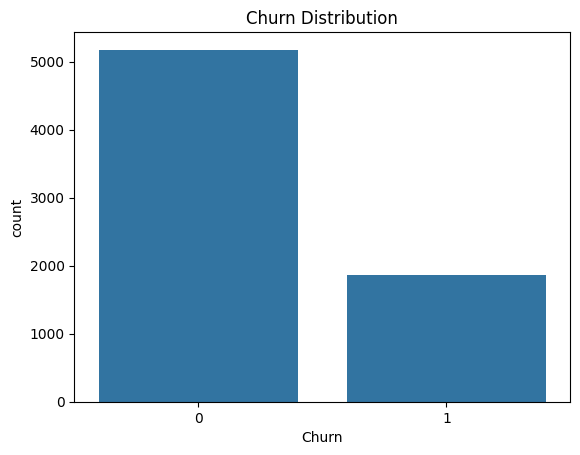

In [5]:
import seaborn as sns
sns.countplot(x="Churn", data=df)
plt.title("Churn Distribution")
plt.show()

Meaning:

Most customers do not churn

Dataset is imbalanced

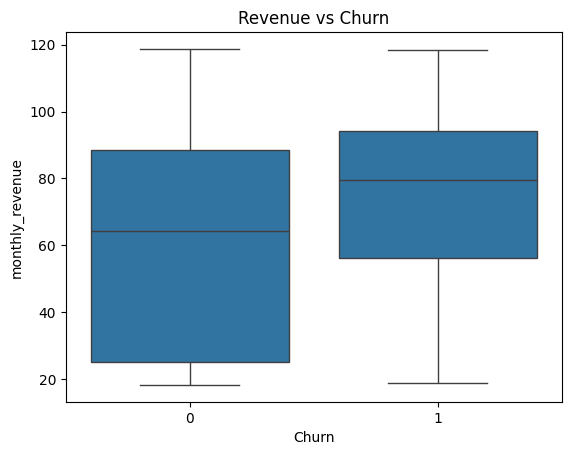

In [6]:
sns.boxplot(x="Churn", y="monthly_revenue", data=df)
plt.title("Revenue vs Churn")
plt.show()

You may observe:

Churn customers sometimes have higher revenue

Losing them impacts business more

This connects ML → Business.

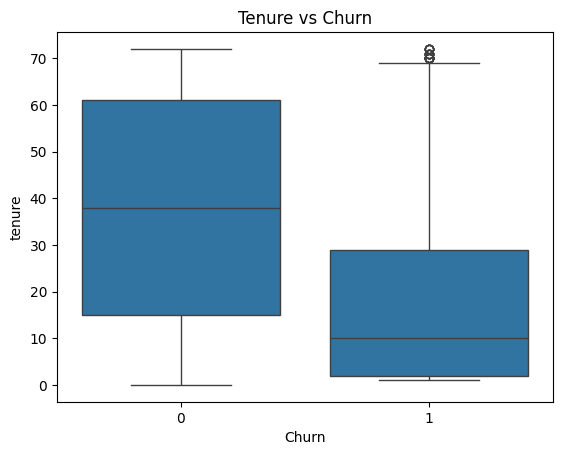

In [7]:
sns.boxplot(x="Churn", y="tenure", data=df)
plt.title("Tenure vs Churn")
plt.show()

Customers with:

Short tenure → higher churn

Long tenure → loyal customers

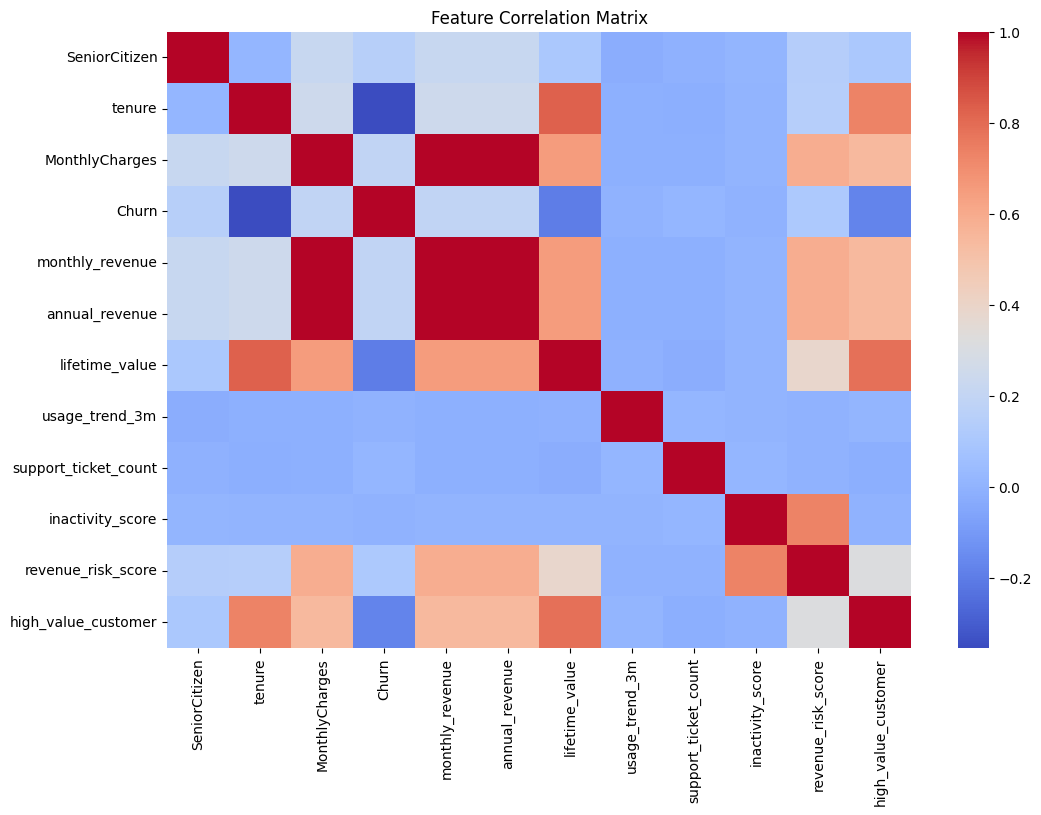

In [8]:
numeric_df = df.select_dtypes(include='number')

corr = numeric_df.corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap="coolwarm")
plt.title("Feature Correlation Matrix")
plt.show()

Retention strategies should focus on new customers in first few months because high tenure low churn probability hence new customer churn more
Create loyalty programs for high-value customers as valuable customers stay longer
Inactive customers are potential churn candidates bcz more inactive customer high revenue risk
Customer complaints may not always lead to churn as Correlation with churn appears very weak.



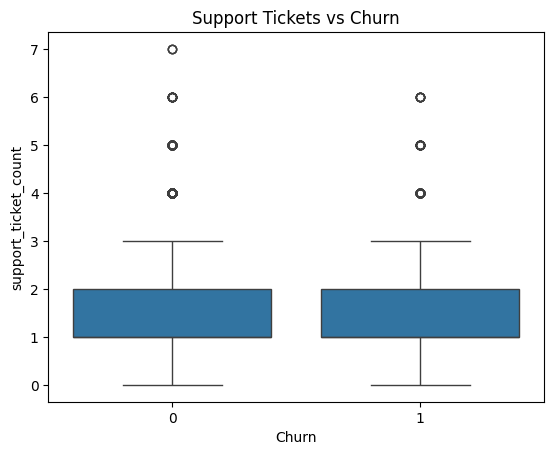

In [9]:
sns.boxplot(x="Churn", y="support_ticket_count", data=df)
plt.title("Support Tickets vs Churn")
plt.show()

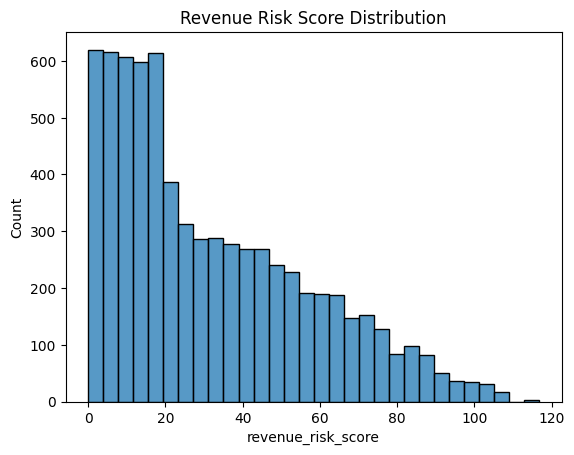

In [10]:
sns.histplot(df["revenue_risk_score"], bins=30)
plt.title("Revenue Risk Score Distribution")
plt.show()

In [1]:
df.corr()["Churn"].sort_values(ascending=False)

NameError: name 'df' is not defined